# 02 — DIP + five-source packaging

Otsu on **ΔNDVI** (deforestation) and **ΔNBR** (fire) → bounding boxes on the **512×512** VLM canvas.

RGB chips use **Sentinel-2 true color** with a fixed reflectance window (`vmax=0.22`, same as GEE `max:2200`). This gives natural green/brown forest terrain — not purple pseudo-color and not neon yellow-green.

All five sources are padded with the **same** transform so tensors align with the RGB chips:

1. Sentinel-2 10-band optical + indices
2. Sentinel-1 VV / VH
3. CHIRPS rainfall
4. ERA5-Land temperature & soil-moisture anomalies
5. DEM elevation / slope / aspect


## 1. Imports


In [1]:
from pathlib import Path
import json
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.dip_utils import (
    SCENE_SUFFIXES,
    apply_reference_class_policy,
    array_nanmean,
    build_disturbance_triplets,
    discover_scenes,
    load_geotiff_hwc,
    load_rgb_geotiff,
    pad_and_resize,
    percentile_stretch_rgb,
    process_tensor_otsu,
    read_single_band,
)

RAW_TIFFS = ROOT / "data" / "raw_tiffs"
PROC = ROOT / "data" / "processed_images"
MASKS = ROOT / "data" / "evidence_masks"
META = ROOT / "data" / "raw_metadata"
TRIPLETS_JSON = META / "triplets.json"
FINAL_LABELS = ROOT.parent / "data" / "labels" / "final_labels.csv"
PROC.mkdir(parents=True, exist_ok=True)
MASKS.mkdir(parents=True, exist_ok=True)
TARGET_SIZE = (512, 512)
MIN_DROP = 0.04  # ignore tiny spectral noise before Otsu
print("discovered suffix keys", list(SCENE_SUFFIXES))


discovered suffix keys ['t0_rgb', 't1_rgb', 't0_optical', 't1_optical', 't0_indices', 't1_indices', 't0_s1', 't1_s1', 't0_rainfall', 't1_rainfall', 't0_era5', 't1_era5', 'dem', 'delta_ndvi', 'delta_nbr']


## 2. Discover complete scenes


In [2]:
scenes = discover_scenes(RAW_TIFFS)
print("complete DIP scenes:", len(scenes))
if scenes:
    print("example keys", sorted(k for k in scenes[0] if k != "scene_id"))


complete DIP scenes: 366
example keys ['delta_nbr', 'delta_ndvi', 'dem', 't0_era5', 't0_indices', 't0_optical', 't0_rainfall', 't0_rgb', 't0_s1', 't1_era5', 't1_indices', 't1_optical', 't1_rainfall', 't1_rgb', 't1_s1']


## 3. Demo cube if GEE TIFFs are not downloaded yet


In [3]:
import rasterio
from rasterio.transform import from_origin


def _write(path, arr, transform):
    arr = np.asarray(arr, dtype=np.float32)
    if arr.ndim == 2:
        arr = arr[None, ...]
    elif arr.ndim == 3:
        arr = np.transpose(arr, (2, 0, 1))
    profile = dict(
        driver="GTiff", height=arr.shape[1], width=arr.shape[2], count=arr.shape[0],
        dtype="float32", crs="EPSG:4326", transform=transform,
    )
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(arr)


def write_demo_cube(raw_dir: Path, scene_id="demo_kanha", h=48, w=72):
    rng = np.random.default_rng(7)
    transform = from_origin(80.7, 22.3, 10, 10)
    y0, y1, x0, x1 = 18, 40, 38, 64
    t0_rgb = np.clip(0.18 + 0.12 * rng.random((h, w, 3)), 0, 1)
    t1_rgb = t0_rgb.copy()
    t1_rgb[y0:y1, x0:x1, 1] *= 0.35
    optical_t0 = np.clip(0.1 + 0.2 * rng.random((h, w, 10)), 0, 1)
    optical_t1 = optical_t0.copy()
    optical_t1[y0:y1, x0:x1, 2] *= 0.5
    indices_t0 = rng.normal(0.6, 0.05, (h, w, 4))
    indices_t1 = indices_t0.copy()
    indices_t1[y0:y1, x0:x1, 0] -= 0.35
    indices_t1[y0:y1, x0:x1, 3] -= 0.42
    s1_t0 = rng.normal(-10, 1.5, (h, w, 2))
    s1_t1 = s1_t0 + rng.normal(0, 0.4, (h, w, 2))
    rain_t0 = np.full((h, w), 72.0)
    rain_t1 = np.full((h, w), 25.0)
    era5_t0 = np.dstack([np.full((h, w), -1.5), np.full((h, w), 0.02)])
    era5_t1 = np.dstack([np.full((h, w), 0.9), np.full((h, w), -0.04)])
    dem = np.dstack([np.full((h, w), 650.0), np.full((h, w), 6.0), np.full((h, w), 180.0)])
    d_ndvi = np.zeros((h, w), np.float32)
    d_nbr = np.zeros((h, w), np.float32)
    d_ndvi[y0:y1, x0:x1] = -0.35
    d_nbr[y0:y1, x0:x1] = -0.42
    d_ndvi += rng.normal(0, 0.02, (h, w)).astype(np.float32)
    d_nbr += rng.normal(0, 0.02, (h, w)).astype(np.float32)
    mapping = {
        f"{scene_id}_T0_rgb.tif": t0_rgb,
        f"{scene_id}_T1_rgb.tif": t1_rgb,
        f"{scene_id}_T0_s2_optical.tif": optical_t0,
        f"{scene_id}_T1_s2_optical.tif": optical_t1,
        f"{scene_id}_T0_indices.tif": indices_t0,
        f"{scene_id}_T1_indices.tif": indices_t1,
        f"{scene_id}_T0_s1.tif": s1_t0,
        f"{scene_id}_T1_s1.tif": s1_t1,
        f"{scene_id}_T0_rainfall.tif": rain_t0,
        f"{scene_id}_T1_rainfall.tif": rain_t1,
        f"{scene_id}_T0_era5.tif": era5_t0,
        f"{scene_id}_T1_era5.tif": era5_t1,
        f"{scene_id}_dem.tif": dem,
        f"{scene_id}_delta_ndvi.tif": d_ndvi,
        f"{scene_id}_delta_nbr.tif": d_nbr,
    }
    for name, arr in mapping.items():
        _write(raw_dir / name, arr, transform)
    print("wrote demo five-source cube", scene_id, f"{h}x{w}")


if not scenes:
    write_demo_cube(RAW_TIFFS)
    scenes = discover_scenes(RAW_TIFFS)
    print("using demo cube until GEE exports land in data/raw_tiffs/")


## 4. Otsu, boxes, aligned 512×512 tensors


In [4]:
csv_path = META / "selected_patches.csv"
patch_csv = pd.read_csv(csv_path) if csv_path.exists() else pd.DataFrame()
scalars_path = META / "patch_scalars.json"
scalars = json.loads(scalars_path.read_text()) if scalars_path.exists() else {}

GEO_COLS = {"lon", "lat", "patch_id"}


def rel(p):
    p = Path(p)
    try:
        return str(p.relative_to(ROOT))
    except ValueError:
        return str(p)


def save_npy(path, arr):
    np.save(path, arr)
    return rel(path)


def pad_stack(path, native_boxes=None):
    hwc = load_geotiff_hwc(path)
    if hwc.shape[-1] == 1:
        hwc = hwc[..., 0]
    out, boxes, meta = pad_and_resize(hwc, TARGET_SIZE, bboxes=native_boxes, keep_dtype=True)
    return out.astype(np.float32), boxes, meta


records = []
final_labels = pd.read_csv(FINAL_LABELS) if FINAL_LABELS.exists() else pd.DataFrame()
ref_map = dict(zip(final_labels.patch_id.astype(str), final_labels.reference_class)) if not final_labels.empty else {}

for scene in scenes:
    sid = scene["scene_id"]
    ndvi_mask = process_tensor_otsu(scene["delta_ndvi"], min_drop=MIN_DROP)
    nbr_mask = process_tensor_otsu(scene["delta_nbr"], min_drop=MIN_DROP)
    delta_ndvi = read_single_band(scene["delta_ndvi"])
    delta_nbr = read_single_band(scene["delta_nbr"])
    native_triplets = build_disturbance_triplets(ndvi_mask, nbr_mask, delta_ndvi, delta_nbr)
    native_triplets = apply_reference_class_policy(native_triplets, ref_map.get(sid))
    native_boxes = [t[0] for t in native_triplets]

    # Fixed S2 true-color window (B4/B3/B2 ÷ 0.22) — natural terrain, not purple or neon
    t0_rgb = percentile_stretch_rgb(load_rgb_geotiff(scene["t0_rgb"]))
    t1_rgb = percentile_stretch_rgb(load_rgb_geotiff(scene["t1_rgb"]))
    t0_512, boxes_512, meta = pad_and_resize(t0_rgb, TARGET_SIZE, bboxes=native_boxes)
    t1_512, _, _ = pad_and_resize(t1_rgb, TARGET_SIZE, bboxes=native_boxes)
    vlm_triplets = [[b, t[1], t[2]] for b, t in zip(boxes_512, native_triplets)]

    t0_jpg = PROC / f"{sid}_T0.jpg"
    t1_jpg = PROC / f"{sid}_T1.jpg"
    Image.fromarray(t0_512).save(t0_jpg, quality=95)
    Image.fromarray(t1_512).save(t1_jpg, quality=95)

    ndvi_512, _, _ = pad_and_resize((ndvi_mask * 255).astype(np.uint8), TARGET_SIZE)
    nbr_512, _, _ = pad_and_resize((nbr_mask * 255).astype(np.uint8), TARGET_SIZE)
    np.save(MASKS / f"{sid}_delta_ndvi_mask.npy", ndvi_512)
    np.save(MASKS / f"{sid}_delta_nbr_mask.npy", nbr_512)

    paths = {
        "t0_image": rel(t0_jpg),
        "t1_image": rel(t1_jpg),
        "delta_ndvi_mask": rel(MASKS / f"{sid}_delta_ndvi_mask.npy"),
        "delta_nbr_mask": rel(MASKS / f"{sid}_delta_nbr_mask.npy"),
    }
    tensor_map = {
        "t0_optical": "t0_optical",
        "t1_optical": "t1_optical",
        "t0_indices": "t0_indices",
        "t1_indices": "t1_indices",
        "t0_s1": "t0_s1",
        "t1_s1": "t1_s1",
        "t0_rainfall": "t0_rainfall",
        "t1_rainfall": "t1_rainfall",
        "t0_era5": "t0_era5",
        "t1_era5": "t1_era5",
        "dem": "dem",
        "delta_ndvi": "delta_ndvi",
        "delta_nbr": "delta_nbr",
    }
    raster_means = {}
    for key, scene_key in tensor_map.items():
        if scene_key not in scene:
            continue
        arr, _, _ = pad_stack(scene[scene_key])
        npy_path = PROC / f"{sid}_{key}.npy"
        paths[key] = save_npy(npy_path, arr)
        paths[f"{key}_tif"] = rel(scene[scene_key])
        raster_means[f"{key}_mean"] = array_nanmean(arr)

    csv_row = {}
    if not patch_csv.empty and "patch_id" in patch_csv.columns:
        hit = patch_csv[patch_csv["patch_id"].astype(str) == sid]
        if len(hit):
            csv_row = {k: v for k, v in hit.iloc[0].to_dict().items() if k not in GEO_COLS}

    records.append({
        "scene_id": sid,
        "native_shape": list(t0_rgb.shape[:2]),
        "vlm_size": list(TARGET_SIZE),
        "pad_meta": {k: (list(v) if isinstance(v, tuple) else v) for k, v in meta.items()},
        "triplets_native": native_triplets,
        "triplets": vlm_triplets,
        "paths": paths,
        "raster_means": raster_means,
        "scalars": scalars.get(sid, {}),
        "csv_stats": csv_row,
        "sources_present": {
            "sentinel2_rgb": True,
            "sentinel2_optical10": "t0_optical" in scene,
            "sentinel1_vv_vh": "t0_s1" in scene,
            "chirps": "t0_rainfall" in scene,
            "era5_temp_sm": "t0_era5" in scene,
            "dem": "dem" in scene,
        },
    })
    print(f"{sid}: {len(vlm_triplets)} boxes | sources {records[-1]['sources_present']}")

TRIPLETS_JSON.write_text(json.dumps(records, indent=2, default=str))
print("wrote", TRIPLETS_JSON)


p00000: 0 boxes | sources {'sentinel2_rgb': True, 'sentinel2_optical10': True, 'sentinel1_vv_vh': True, 'chirps': True, 'era5_temp_sm': True, 'dem': True}
p00028: 0 boxes | sources {'sentinel2_rgb': True, 'sentinel2_optical10': True, 'sentinel1_vv_vh': True, 'chirps': True, 'era5_temp_sm': True, 'dem': True}
p00031: 0 boxes | sources {'sentinel2_rgb': True, 'sentinel2_optical10': True, 'sentinel1_vv_vh': True, 'chirps': True, 'era5_temp_sm': True, 'dem': True}
p00044: 0 boxes | sources {'sentinel2_rgb': True, 'sentinel2_optical10': True, 'sentinel1_vv_vh': True, 'chirps': True, 'era5_temp_sm': True, 'dem': True}
p00052: 2 boxes | sources {'sentinel2_rgb': True, 'sentinel2_optical10': True, 'sentinel1_vv_vh': True, 'chirps': True, 'era5_temp_sm': True, 'dem': True}
p00086: 0 boxes | sources {'sentinel2_rgb': True, 'sentinel2_optical10': True, 'sentinel1_vv_vh': True, 'chirps': True, 'era5_temp_sm': True, 'dem': True}
p00100: 0 boxes | sources {'sentinel2_rgb': True, 'sentinel2_optical10

## 5. Sample triplet


In [5]:
sample = records[0]
print("scene", sample["scene_id"])
print("sources", sample["sources_present"])
print("sample triplet", sample["triplets"][0] if sample["triplets"] else None)
print("format: [[x_min, y_min, x_max, y_max], type, severity]")


scene p00000
sources {'sentinel2_rgb': True, 'sentinel2_optical10': True, 'sentinel1_vv_vh': True, 'chirps': True, 'era5_temp_sm': True, 'dem': True}
sample triplet None
format: [[x_min, y_min, x_max, y_max], type, severity]


## 6. Visual QA (natural-color terrain view)

Re-run section 4 first if you still see purple — old JPGs were saved with the previous per-band stretch.


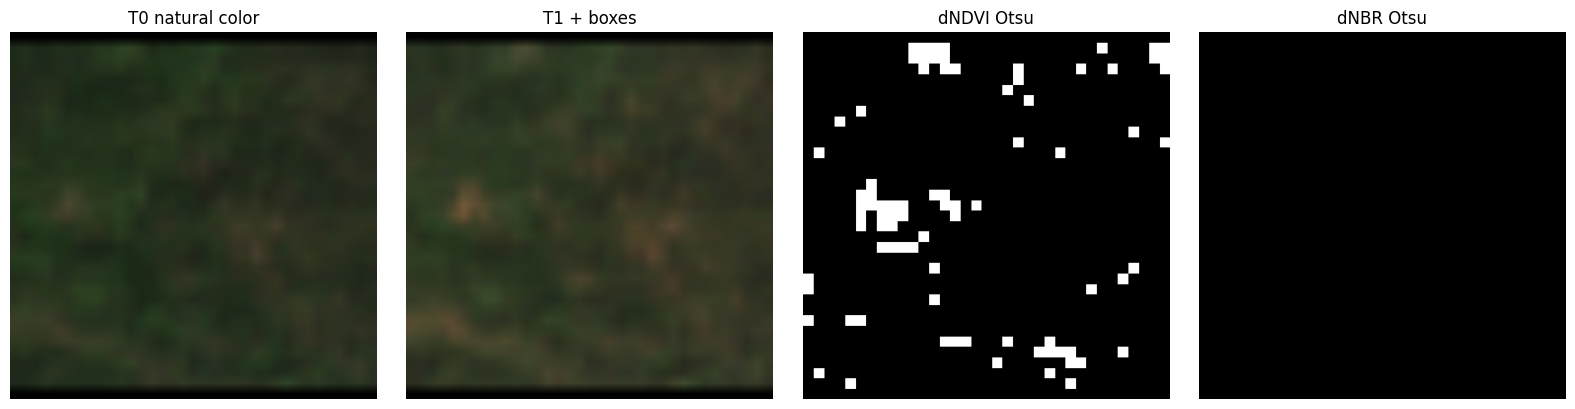

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
t0 = np.array(Image.open(ROOT / sample["paths"]["t0_image"]))
t1 = np.array(Image.open(ROOT / sample["paths"]["t1_image"]))
overlay = t1.copy()
for box, dtype, sev in sample["triplets"]:
    x0, y0, x1, y1 = box
    color = (255, 80, 40) if dtype == "Fire" else (40, 200, 80)
    cv2.rectangle(overlay, (x0, y0), (x1, y1), color, 2)
    cv2.putText(overlay, f"{dtype}:{sev}", (x0, max(12, y0 - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
ndvi_m = np.load(ROOT / sample["paths"]["delta_ndvi_mask"])
nbr_m = np.load(ROOT / sample["paths"]["delta_nbr_mask"])
axes[0].imshow(t0); axes[0].set_title("T0 natural color")
axes[1].imshow(overlay); axes[1].set_title("T1 + boxes")
axes[2].imshow(ndvi_m, cmap="gray"); axes[2].set_title("dNDVI Otsu")
axes[3].imshow(nbr_m, cmap="gray"); axes[3].set_title("dNBR Otsu")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()
